In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
sys.path.append(os.path.abspath('../'))

In [31]:
df = pd.read_csv('C:\py\Retail-Sales-Analysis\data\superstore_dataset.csv')
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


In [32]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 18  profit_m

order_id         0
order_date       0
ship_date        0
customer         0
manufactory      0
product_name     0
segment          0
category         0
subcategory      0
region           0
zip              0
city             0
state            0
country          0
discount         0
profit           0
quantity         0
sales            0
profit_margin    0
dtype: int64

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
# Convert dates
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# Remove duplicates (just in case)
df.drop_duplicates(inplace=True)

In [35]:
df[df['sales'] < 0]
df[df['profit'].isnull()]

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin


In [36]:
df['month_year'] = df['order_date'].dt.to_period('M')
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days



In [37]:
df.to_csv('../data/superstore_cleaned.csv', index=False)

Exploratory Data Analysis (EDA)


In [38]:
df = pd.read_csv('../data/superstore_cleaned.csv')



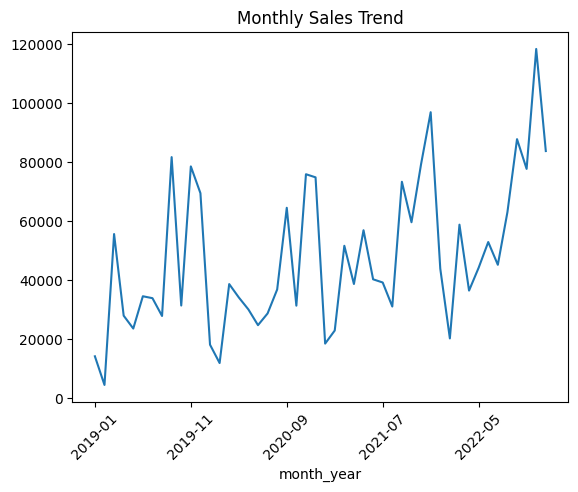

In [39]:
# now it works
monthly_sales = df.groupby('month_year')['sales'].sum()

monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

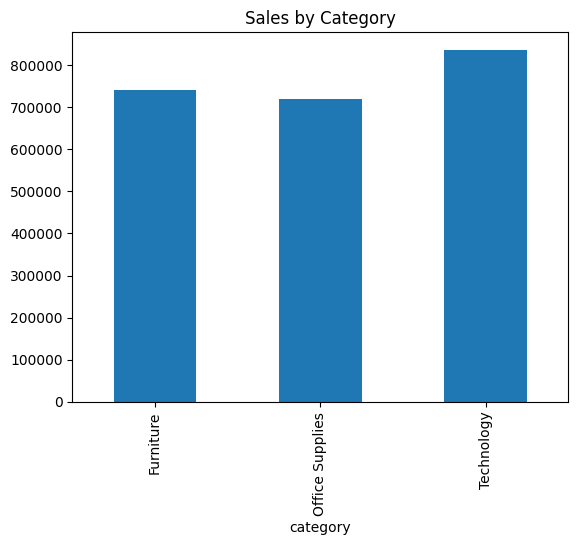

In [40]:
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.show()

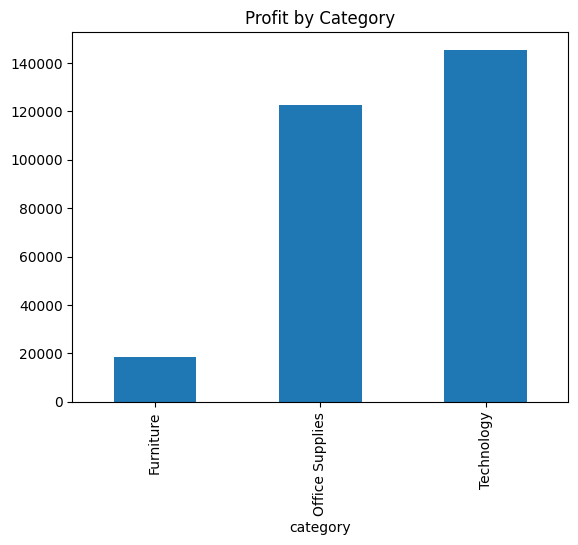

In [41]:
df.groupby('category')['profit'].sum().plot(kind='bar')
plt.title('Profit by Category')
plt.show()

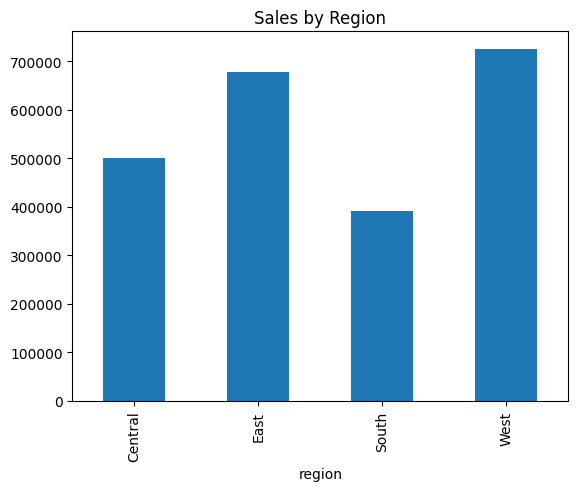

In [42]:
df.groupby('region')['sales'].sum().plot(kind='bar')
plt.title('Sales by Region')
plt.show()

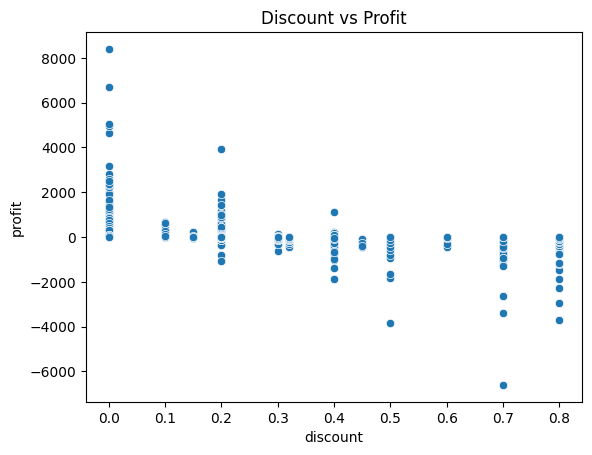

In [43]:
sns.scatterplot(x='discount', y='profit', data=df)
plt.title('Discount vs Profit')
plt.show()

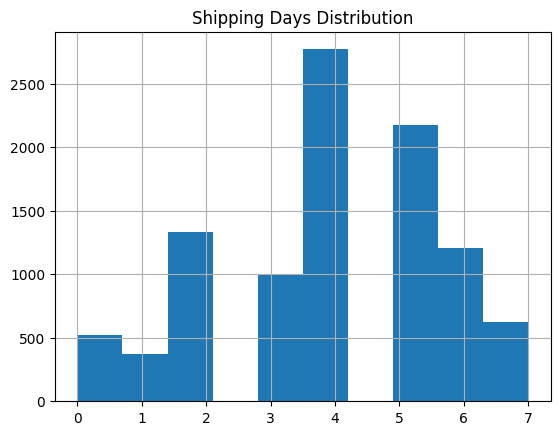

In [44]:
df['shipping_days'].hist()
plt.title('Shipping Days Distribution')
plt.show()

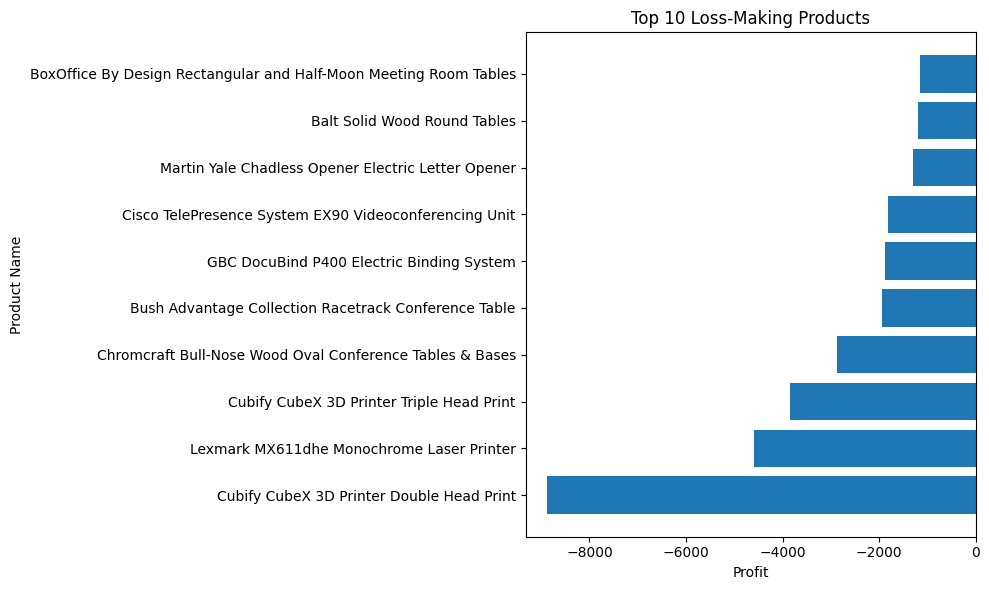

In [47]:
top_loss = loss_products.sort_values(by='profit').head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_loss['product_name'], top_loss['profit'])
plt.title('Top 10 Loss-Making Products')
plt.xlabel('Profit')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

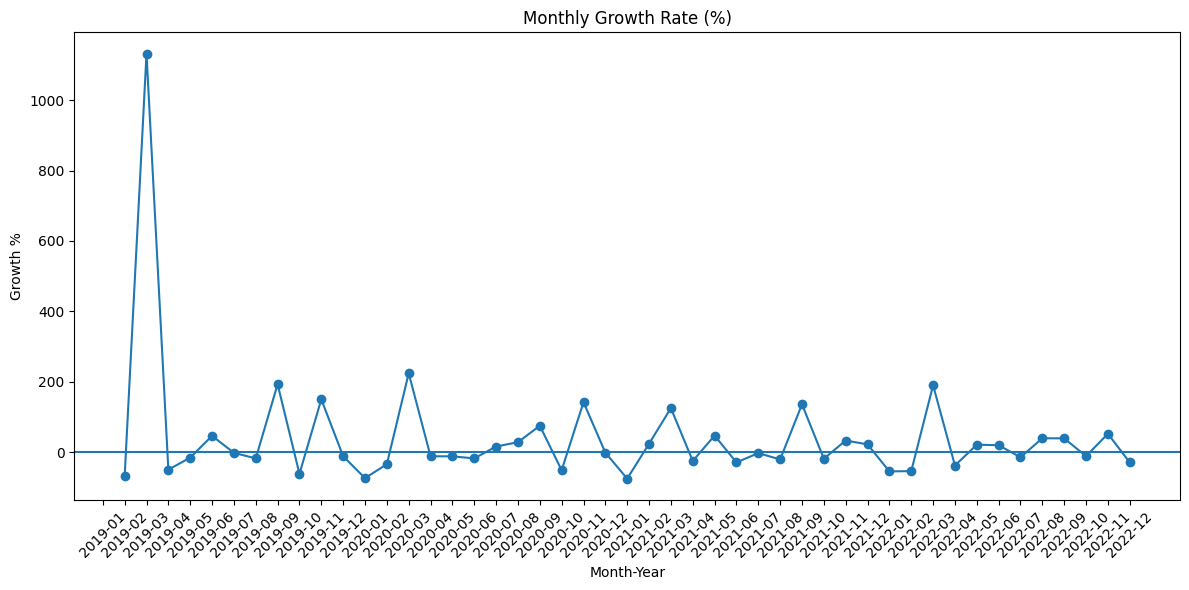

In [48]:
monthly_sales = df.groupby('month_year')['sales'].sum().reset_index()
monthly_sales['growth_rate'] = monthly_sales['sales'].pct_change() * 100

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['month_year'].astype(str), monthly_sales['growth_rate'], marker='o')

plt.axhline(0)  # reference line
plt.title('Monthly Growth Rate (%)')
plt.xlabel('Month-Year')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

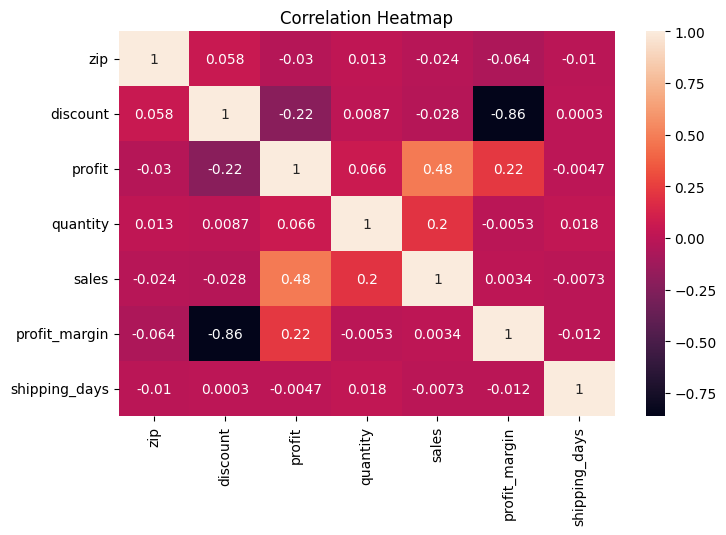

In [49]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()